# 02 — Retrieval Performance

Recall@K & MRR overview, per-decile performance, document length analysis,
and point cloud plots. One line per strategy; colours and labels come from
`shared_setup.strategy_colors` and `shared_setup.strategy_label`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.eval.shared_setup import *

✓ Boundaries loaded (UW: 1.0000…175763168.0000)
  ✓ elasticsearch / approximation: loading from cache
    excluded 22,922 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
  ✓ elasticsearch / bm25: loading from cache
    excluded 22,922 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
  ✓ faiss / ivfpq: loading from cache
    excluded 22,922 rows matching EXCLUDED_DATASETS (['hotpot_qa', 'trex'])
✓ Metrics loaded from cache
✓ Per-decile metrics loaded from cache

✓ shared_setup complete — 3 strategies ready
  Collection : wiki_full_bil
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
  Backends   : {'elasticsearch': ['approximation', 'bm25'], 'faiss': ['ivfpq']}
  Strategies : ['approximation', 'bm25', 'ivfpq']
  Decile mode: chunk_weighted
  Group col  : dataset


## Recall@K & MRR Overview

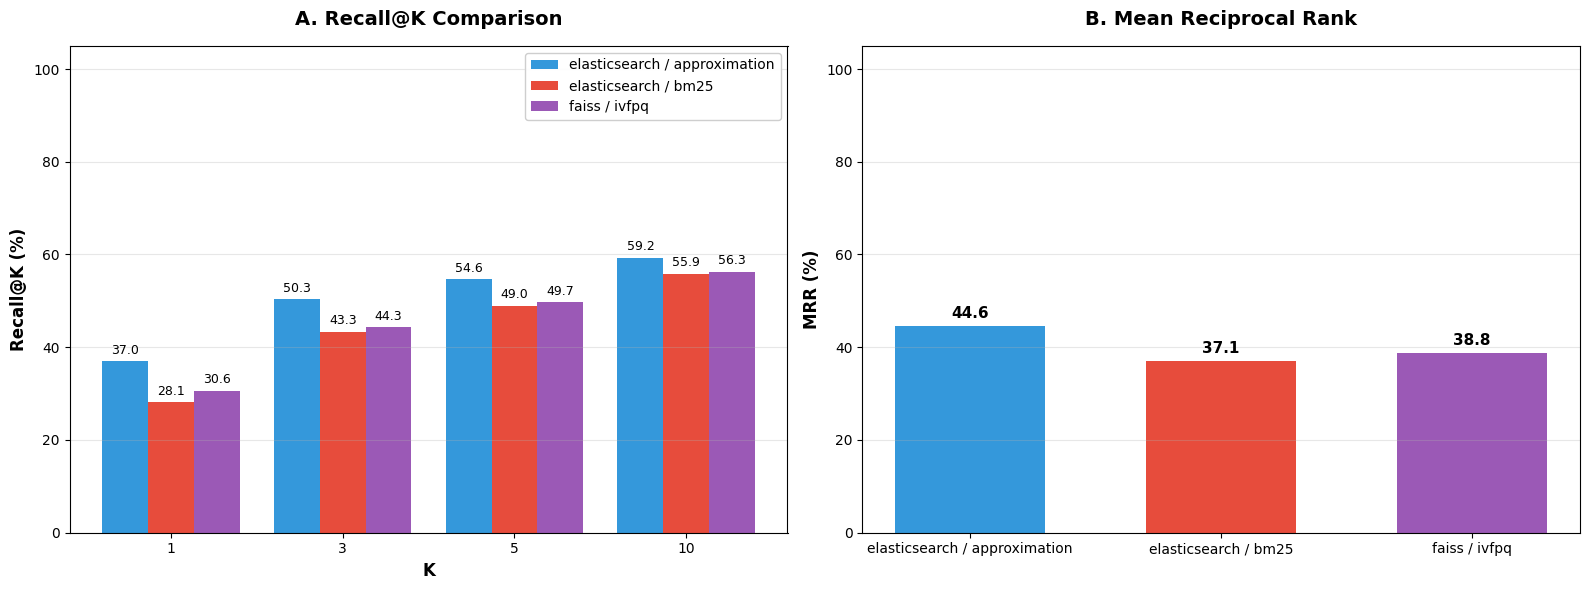

✓ Saved → performance_overview.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
x = np.arange(len(K_VALUES_DETAILED))
width = 0.8 / len(ALL_STRATEGIES)
for i, strategy in enumerate(ALL_STRATEGIES):
    recalls = [metrics_by_strategy[strategy].get(f'recall@{k}', 0) for k in K_VALUES_DETAILED]
    color = strategy_colors.get(strategy)
    bars = ax.bar(x + i * width, np.array(recalls) * 100, width,
                  label=strategy_label(strategy), color=color)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=9)
ax.set_xlabel('K', fontsize=12, fontweight='bold')
ax.set_ylabel('Recall@K (%)', fontsize=12, fontweight='bold')
ax.set_title('A. Recall@K Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width * (len(ALL_STRATEGIES) - 1) / 2)
ax.set_xticklabels(K_VALUES_DETAILED)
ax.legend(fontsize=10, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

ax = axes[1]
mrr_values = [metrics_by_strategy[s].get('mrr', 0) * 100 for s in ALL_STRATEGIES]
colors = [strategy_colors.get(s) for s in ALL_STRATEGIES]
bars = ax.bar(range(len(ALL_STRATEGIES)), mrr_values, color=colors, width=0.6)
for bar, val in zip(bars, mrr_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('MRR (%)', fontsize=12, fontweight='bold')
ax.set_title('B. Mean Reciprocal Rank', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(range(len(ALL_STRATEGIES)))
ax.set_xticklabels([strategy_label(s) for s in ALL_STRATEGIES], fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'performance_overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved → performance_overview.png')

## Per-Decile Recall@K & MRR

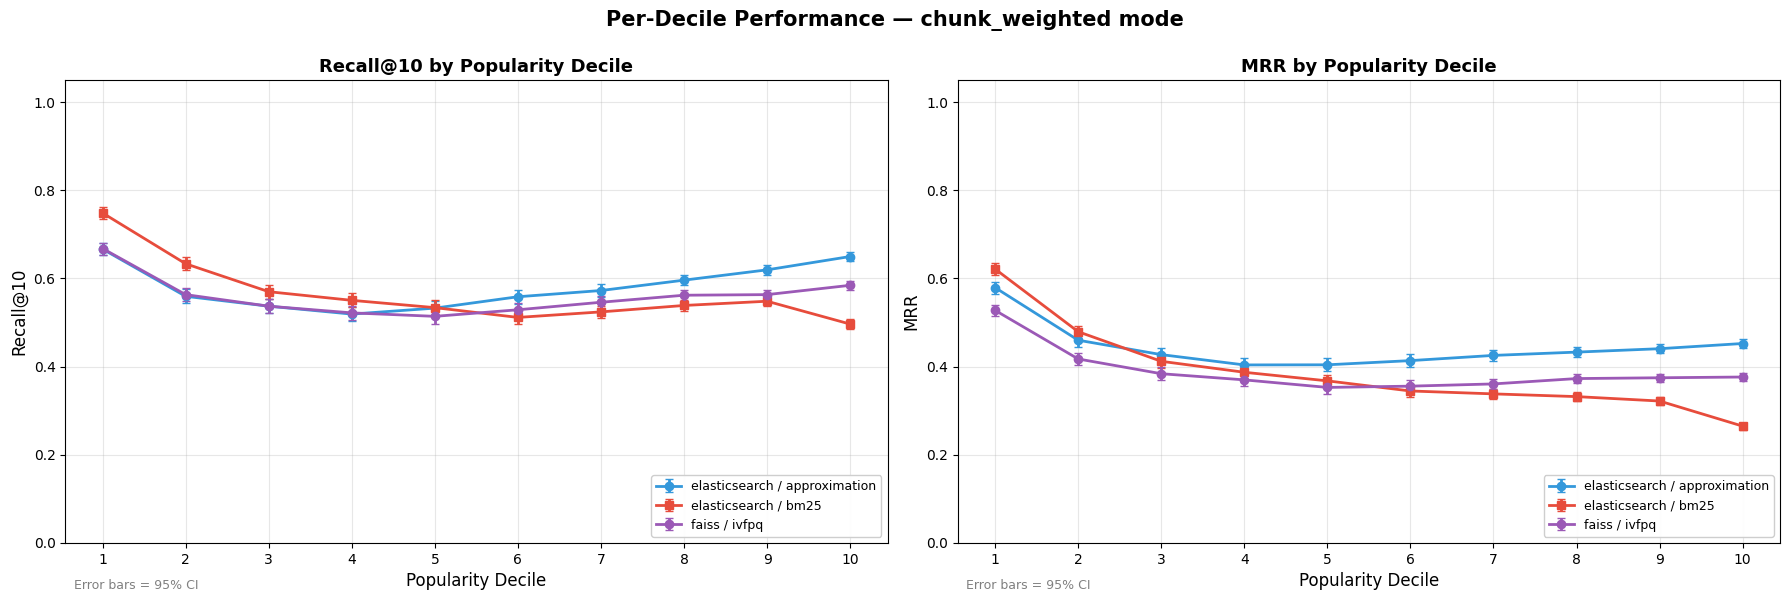

✓ Saved → per_decile_performance.png


In [3]:
primary_k = K_VALUES_DETAILED[-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, ylabel, title in [
    (axes[0], f'recall@{primary_k}', f'Recall@{primary_k}', f'Recall@{primary_k} by Popularity Decile'),
    (axes[1], 'mrr',                 'MRR',                  'MRR by Popularity Decile'),
]:
    for strategy in ALL_STRATEGIES:
        dm = decile_metrics_by_strategy[strategy]
        if metric not in dm.columns:
            continue
        ci_col = f'{metric}_ci95'
        se_col = f'{metric}_se'
        x    = dm['decile'] + 1
        y    = dm[metric]
        yerr = (dm[ci_col] if ci_col in dm.columns
                else dm[se_col] * 1.96 if se_col in dm.columns
                else np.zeros(len(y)))
        ax.errorbar(x, y, yerr=yerr, marker=markers.get(strategy, 'o'),
                    linewidth=2, markersize=6, capsize=3,
                    color=strategy_colors.get(strategy),
                    label=strategy_label(strategy))
    ax.set_xlabel('Popularity Decile', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
    ax.text(0.01, -0.10, 'Error bars = 95% CI', transform=ax.transAxes, fontsize=9, color='gray')
    ax.legend(fontsize=9, loc='lower right', framealpha=0.95)

plt.suptitle(f'Per-Decile Performance — {DECILE_MODE} mode', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_decile_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → per_decile_performance.png')

## Document Length Per Decile

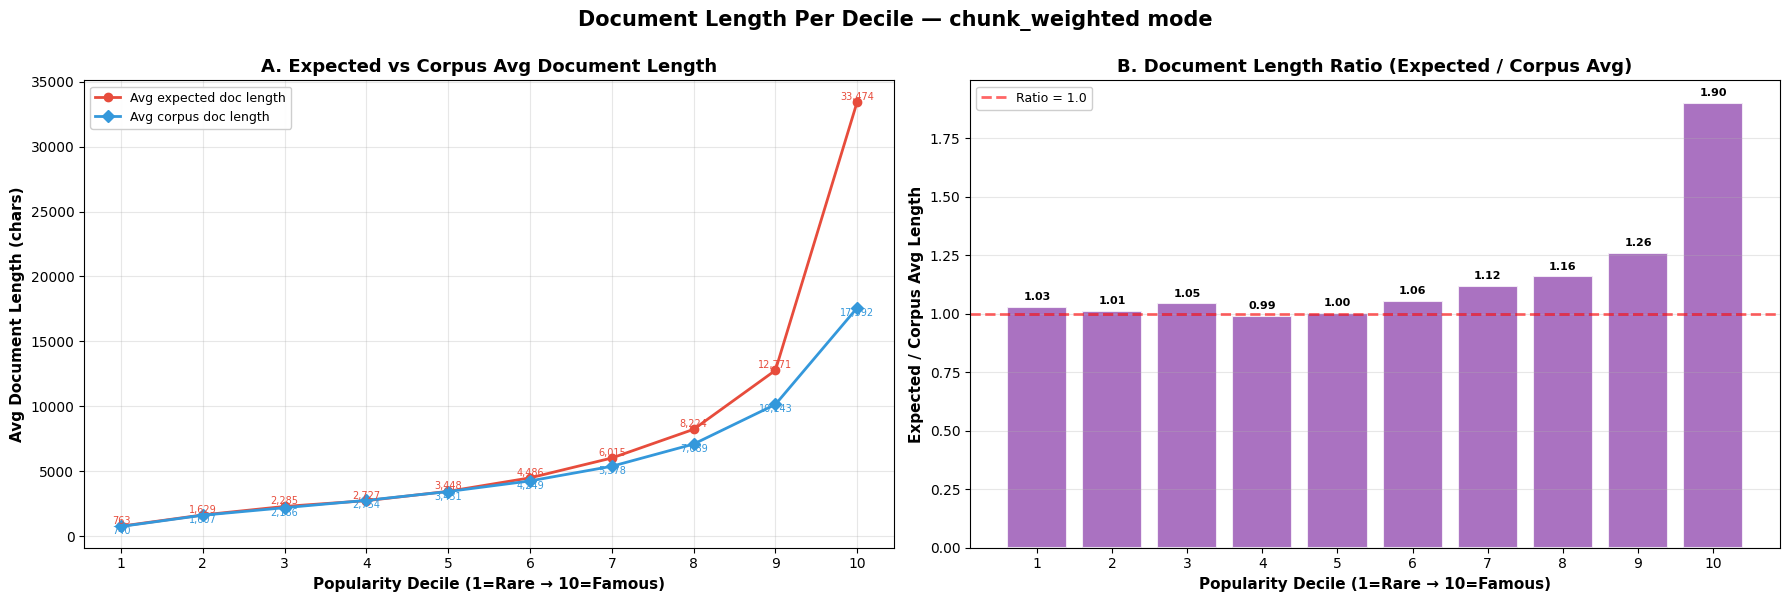

✓ Saved → doc_length_per_decile.png


In [4]:
# Use first strategy for doc-length panels (corpus-level, same across all strategies)
dm0 = decile_metrics_by_strategy[ALL_STRATEGIES[0]]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
x_dec = dm0['decile'] + 1
if 'avg_expected_doc_length' in dm0.columns and dm0['avg_expected_doc_length'].notna().any():
    ax.plot(x_dec, dm0['avg_expected_doc_length'], marker='o', linewidth=2, markersize=6,
            color='#e74c3c', label='Avg expected doc length')
    for xi, yi in zip(x_dec, dm0['avg_expected_doc_length']):
        if not np.isnan(yi):
            ax.text(xi, yi, f'{yi:,.0f}', ha='center', va='bottom', fontsize=7, color='#e74c3c')
if 'avg_corpus_doc_length' in dm0.columns and dm0['avg_corpus_doc_length'].notna().any():
    ax.plot(x_dec, dm0['avg_corpus_doc_length'], marker='D', linewidth=2, markersize=6,
            color='#3498db', label='Avg corpus doc length')
    for xi, yi in zip(x_dec, dm0['avg_corpus_doc_length']):
        if not np.isnan(yi):
            ax.text(xi, yi, f'{yi:,.0f}', ha='center', va='top', fontsize=7, color='#3498db')
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontsize=11, fontweight='bold')
ax.set_ylabel('Avg Document Length (chars)', fontsize=11, fontweight='bold')
ax.set_title('A. Expected vs Corpus Avg Document Length', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, framealpha=0.95)

ax = axes[1]
if 'doc_length_ratio' in dm0.columns and dm0['doc_length_ratio'].notna().any():
    ratio_vals = dm0['doc_length_ratio']
    ax.bar(x_dec, ratio_vals, color='#9b59b6', edgecolor='white', linewidth=1.5, alpha=0.85)
    for xi, ri in zip(x_dec, ratio_vals):
        if not np.isnan(ri):
            ax.text(xi, ri + 0.02, f'{ri:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ratio = 1.0')
    ax.legend(fontsize=9, framealpha=0.95)
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontsize=11, fontweight='bold')
ax.set_ylabel('Expected / Corpus Avg Length', fontsize=11, fontweight='bold')
ax.set_title('B. Document Length Ratio (Expected / Corpus Avg)', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'Document Length Per Decile — {DECILE_MODE} mode', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'doc_length_per_decile.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved → doc_length_per_decile.png')

## Performance vs ln(Popularity) — Point Cloud

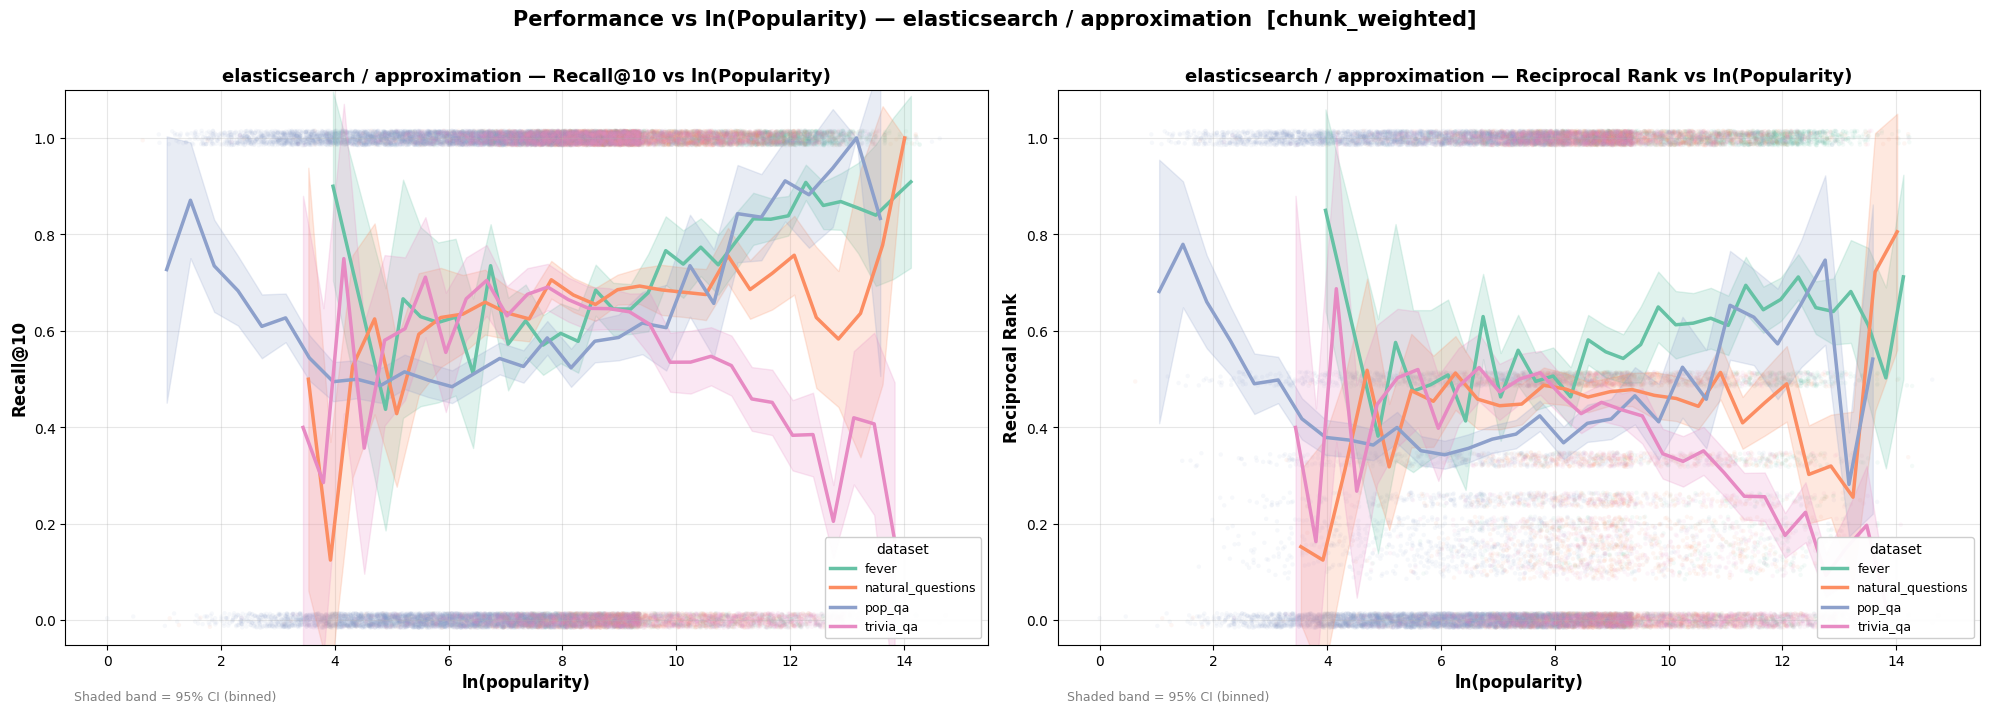

✓ Saved → pointcloud_performance_approximation.png


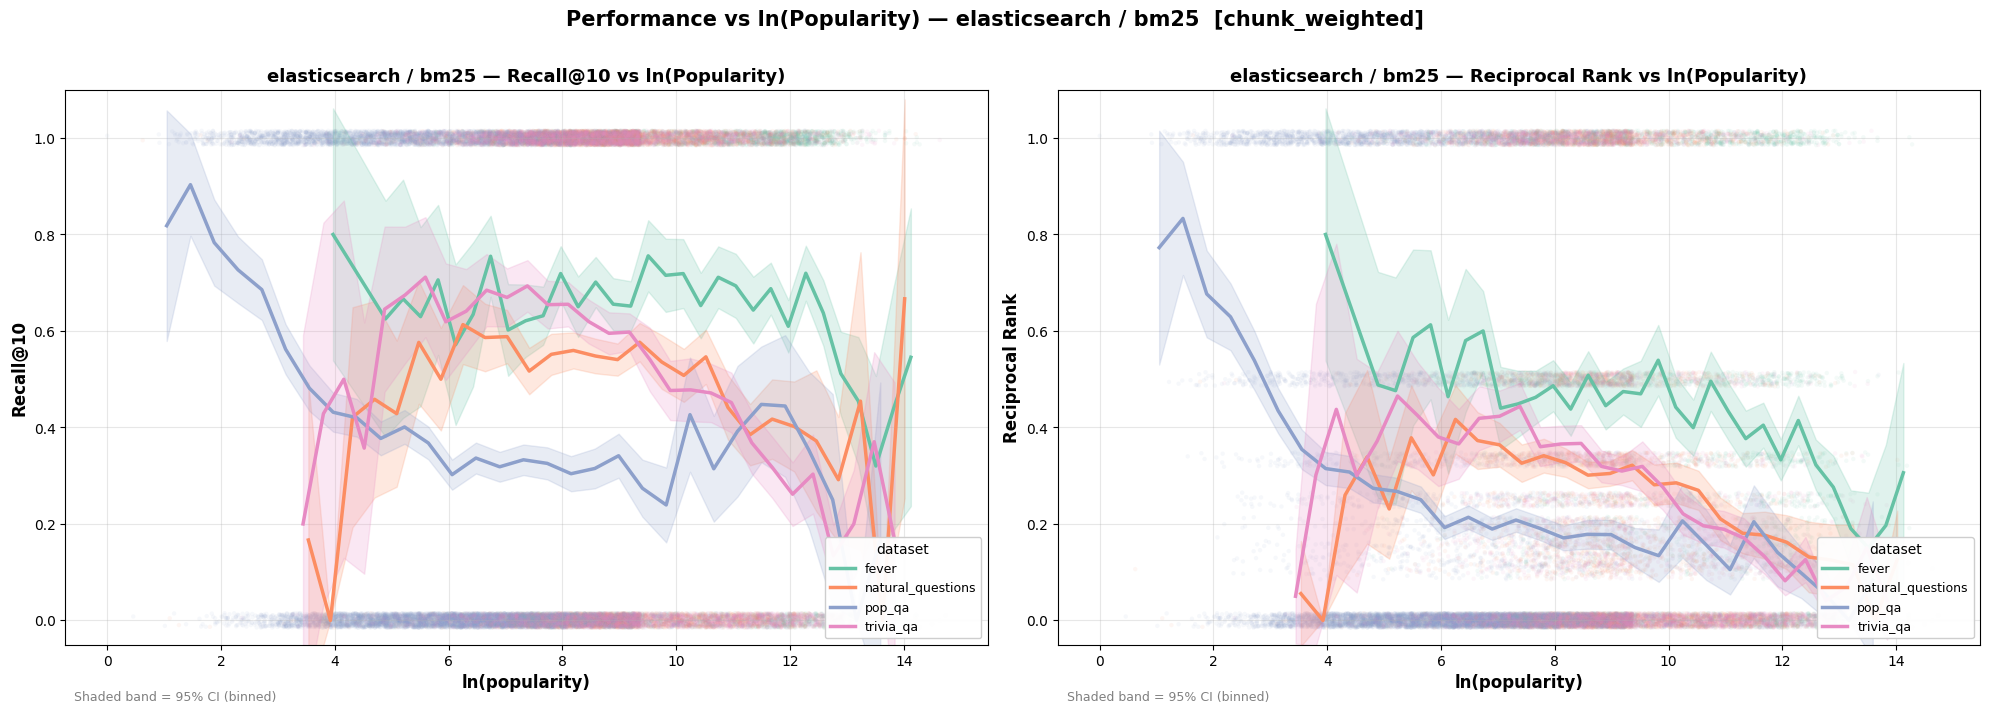

✓ Saved → pointcloud_performance_bm25.png


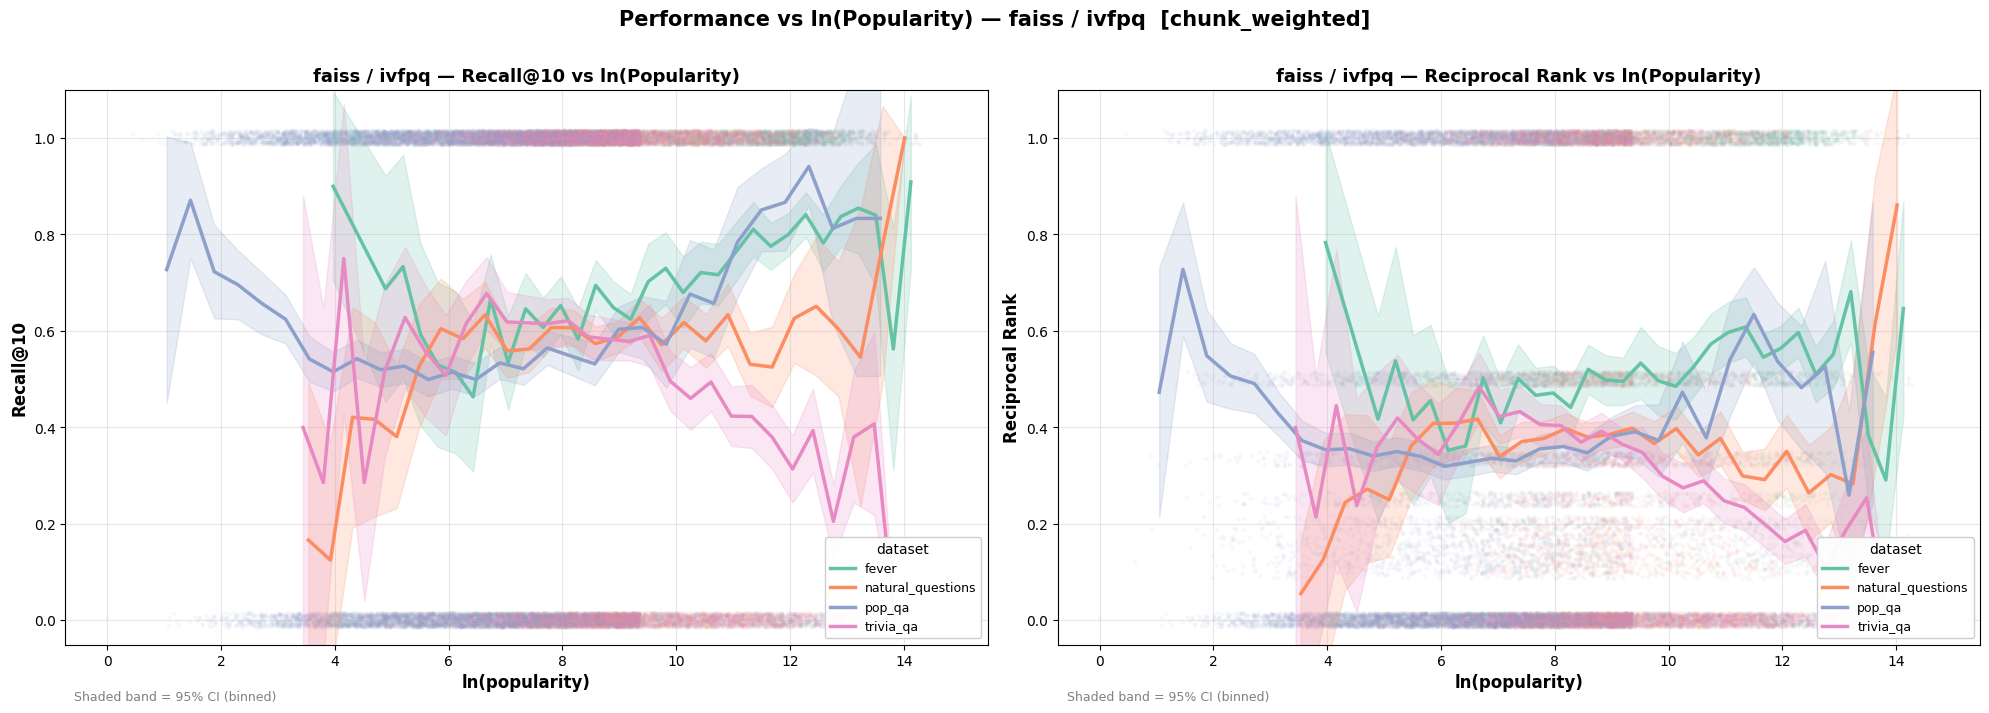

✓ Saved → pointcloud_performance_ivfpq.png


In [5]:
from src.metrics.metrics import binned_stats as _binned_stats

primary_k  = K_VALUES_DETAILED[-1]
recall_col = f'recall@{primary_k}'

def _plot_panel(ax, df, metric_col, datasets, palette, has_dataset, title, ylabel):
    rng = np.random.default_rng(42)
    for ds in datasets:
        sub = df[df[GROUP_COL] == ds].copy() if has_dataset else df.copy()
        colour = palette[ds]
        x = sub['ln_popularity'].values
        y = sub[metric_col].values
        jitter = rng.uniform(-0.015, 0.015, size=len(y))
        ax.scatter(x, np.clip(y + jitter, -0.05, 1.05), alpha=0.07, s=10,
                   color=colour, edgecolors='none', zorder=1)
        if len(sub) > 30:
            fx, fy, fci = _binned_stats(x, y)
            if len(fx) > 2:
                ax.plot(fx, fy, linewidth=2.5, color=colour, label=ds, zorder=3)
                ax.fill_between(fx, fy - fci, fy + fci, color=colour, alpha=0.20, zorder=2)
    ax.set_xlabel('ln(popularity)', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(-0.05, 1.10)
    ax.legend(title=GROUP_COL or 'dataset', fontsize=9, framealpha=0.95, loc='lower right')
    ax.text(0.01, -0.10, 'Shaded band = 95% CI (binned)', transform=ax.transAxes, fontsize=9, color='gray')
    ax.grid(True, alpha=0.3)

for strategy in ALL_STRATEGIES:
    df = results_by_strategy[strategy].copy()
    df = df[df[COL_POPULARITY] > 0].copy()
    df['ln_popularity'] = np.log(df[COL_POPULARITY])
    has_dataset = bool(GROUP_COL) and GROUP_COL in df.columns and df[GROUP_COL].nunique() > 1
    datasets = sorted(df[GROUP_COL].dropna().unique()) if has_dataset else [strategy]
    palette  = dict(zip(datasets, sns.color_palette('Set2', len(datasets))))

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    _plot_panel(axes[0], df, recall_col,        datasets, palette, has_dataset,
                f'{strategy_label(strategy)} — Recall@{primary_k} vs ln(Popularity)', f'Recall@{primary_k}')
    _plot_panel(axes[1], df, 'reciprocal_rank', datasets, palette, has_dataset,
                f'{strategy_label(strategy)} — Reciprocal Rank vs ln(Popularity)', 'Reciprocal Rank')
    plt.suptitle(f'Performance vs ln(Popularity) — {strategy_label(strategy)}  [{DECILE_MODE}]',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'pointcloud_performance_{strategy}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved → pointcloud_performance_{strategy}.png')

## Per-Dataset Recall@K & MRR

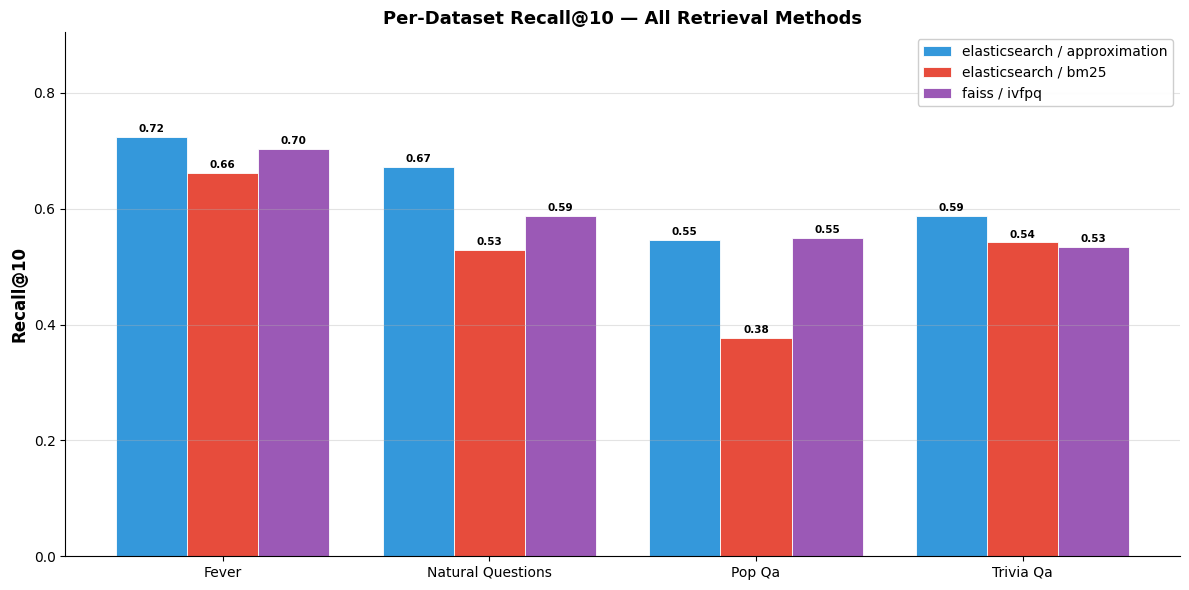

✓ Saved → per_dataset_recall_at_10.png


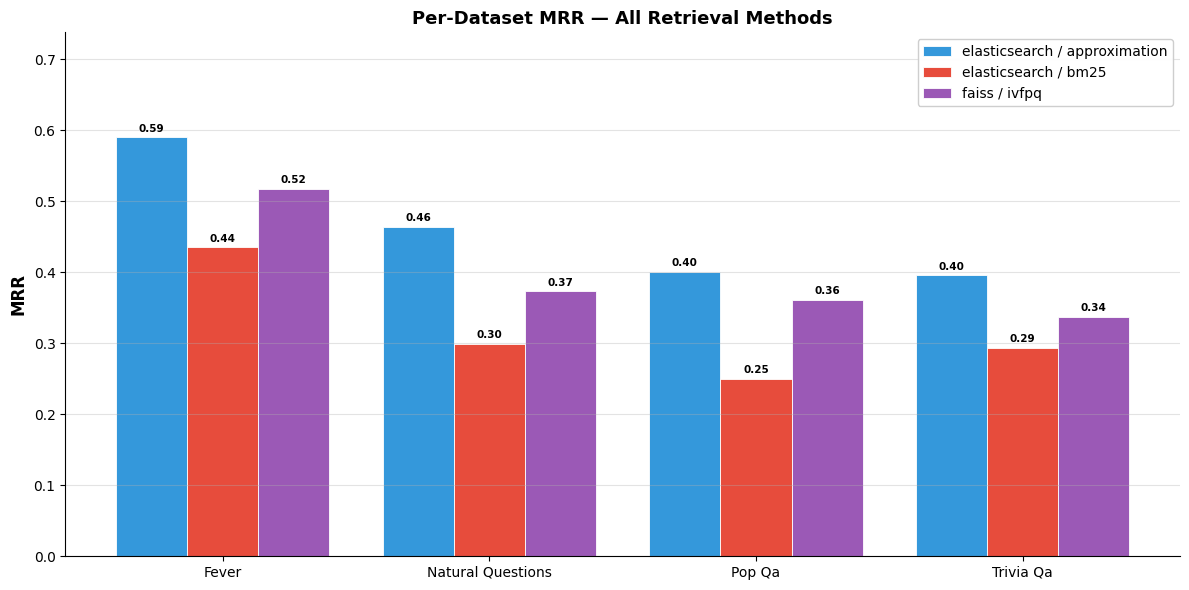

✓ Saved → per_dataset_mrr.png


In [6]:
primary_k = K_VALUES_DETAILED[-1]
recall_col = f"recall@{primary_k}"

if GROUP_COL:
    datasets = sorted(
        set().union(*[results_by_strategy[s][GROUP_COL].dropna().unique()
                       for s in ALL_STRATEGIES])
    )

    # ── compute per-dataset recall & MRR for every strategy ──────────────────
    ds_records = []
    for strategy in ALL_STRATEGIES:
        df = results_by_strategy[strategy]
        for ds in datasets:
            sub = df[df[GROUP_COL] == ds]
            if sub.empty:
                continue
            rec = {
                "strategy": strategy_label(strategy),
                "dataset":  ds,
                recall_col: sub[recall_col].mean() if recall_col in sub.columns else np.nan,
                "mrr":      sub["reciprocal_rank"].mean() if "reciprocal_rank" in sub.columns else np.nan,
            }
            ds_records.append(rec)

    ds_df = pd.DataFrame(ds_records)

    x     = np.arange(len(datasets))
    n_s   = len(ALL_STRATEGIES)
    width = 0.8 / n_s

    for metric, ylabel, title_suffix in [
        (recall_col, f"Recall@{primary_k}", f"Recall@{primary_k}"),
        ("mrr",      "MRR",                 "MRR"),
    ]:
        fig, ax = plt.subplots(figsize=(max(12, len(datasets) * 2), 6))
        for i, strategy in enumerate(ALL_STRATEGIES):
            label = strategy_label(strategy)
            sub   = ds_df[ds_df["strategy"] == label]
            vals  = [sub[sub["dataset"] == ds][metric].values[0]
                     if ds in sub["dataset"].values else np.nan
                     for ds in datasets]
            offset = (i - n_s / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=label,
                          color=strategy_colors[strategy], edgecolor="white", linewidth=0.6)
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                            f"{v:.2f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels([d.replace("_", " ").title() for d in datasets], fontsize=10)
        ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
        ax.set_title(f"Per-Dataset {title_suffix} — All Retrieval Methods", fontsize=13, fontweight="bold")
        ax.set_ylim(0, min(1.15, ds_df[metric].max() * 1.25) if ds_df[metric].notna().any() else 1.0)
        ax.legend(fontsize=10, framealpha=0.95)
        ax.grid(axis="y", alpha=0.35)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        fname = f"per_dataset_{metric.replace('@', '_at_')}.png"
        plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved → {fname}")
else:
    print("No GROUP_COL found — skipping per-dataset comparison.")


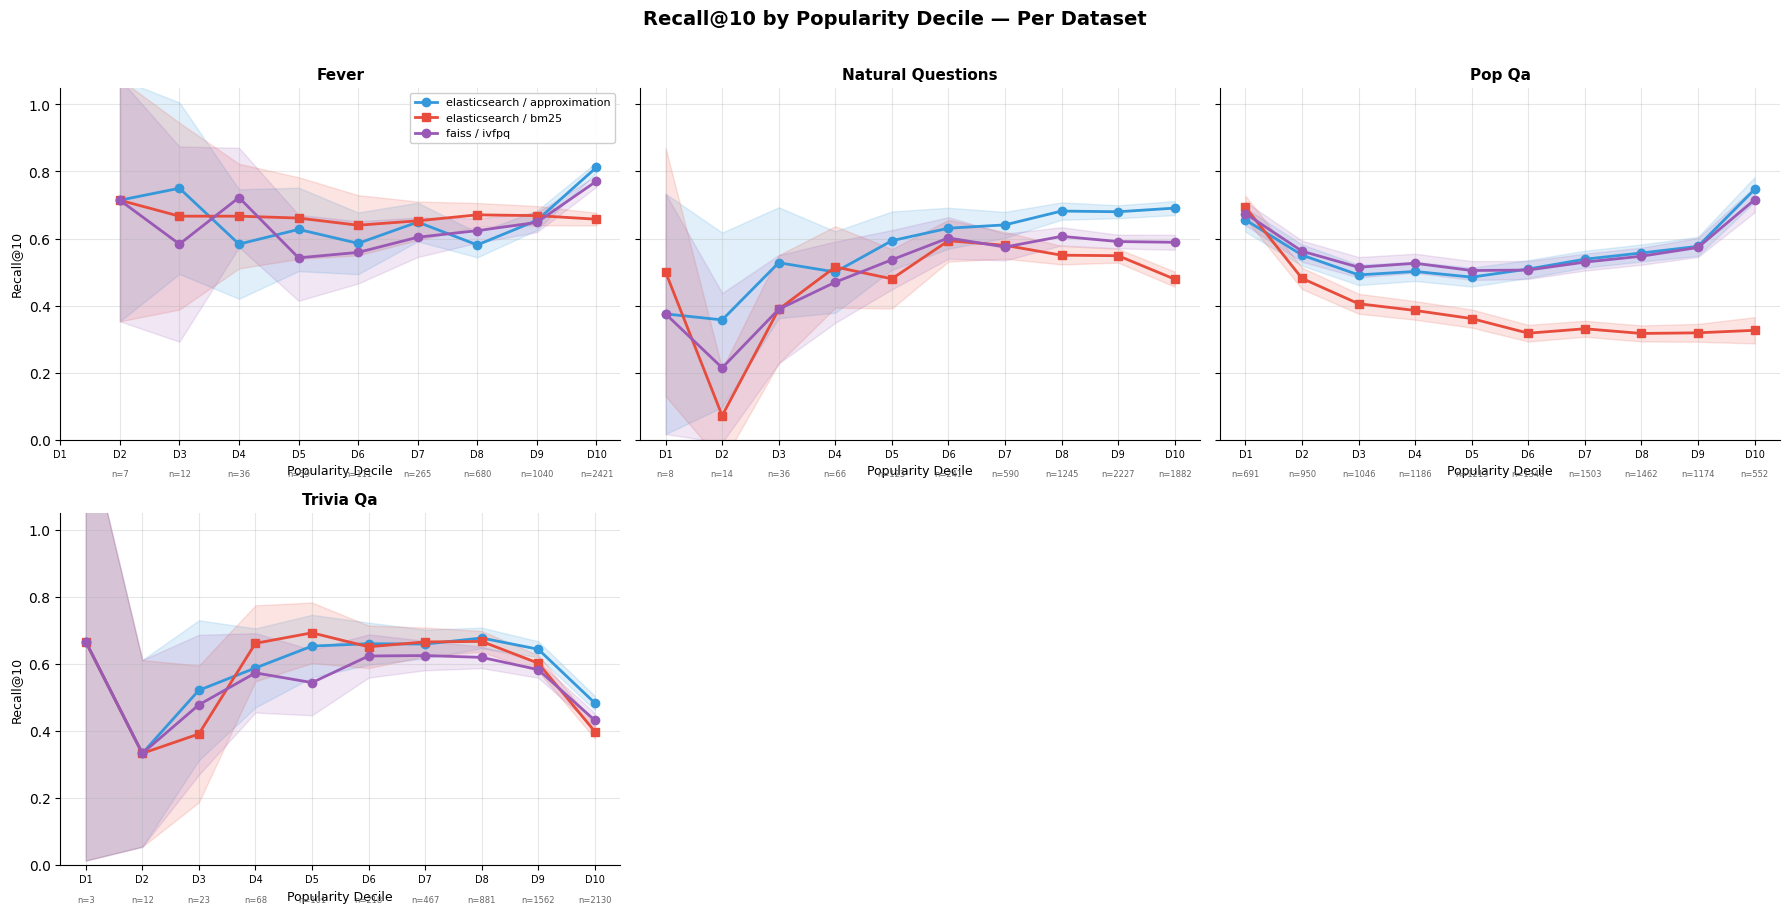

✓ Saved → per_dataset_decile_recall_at_10.png


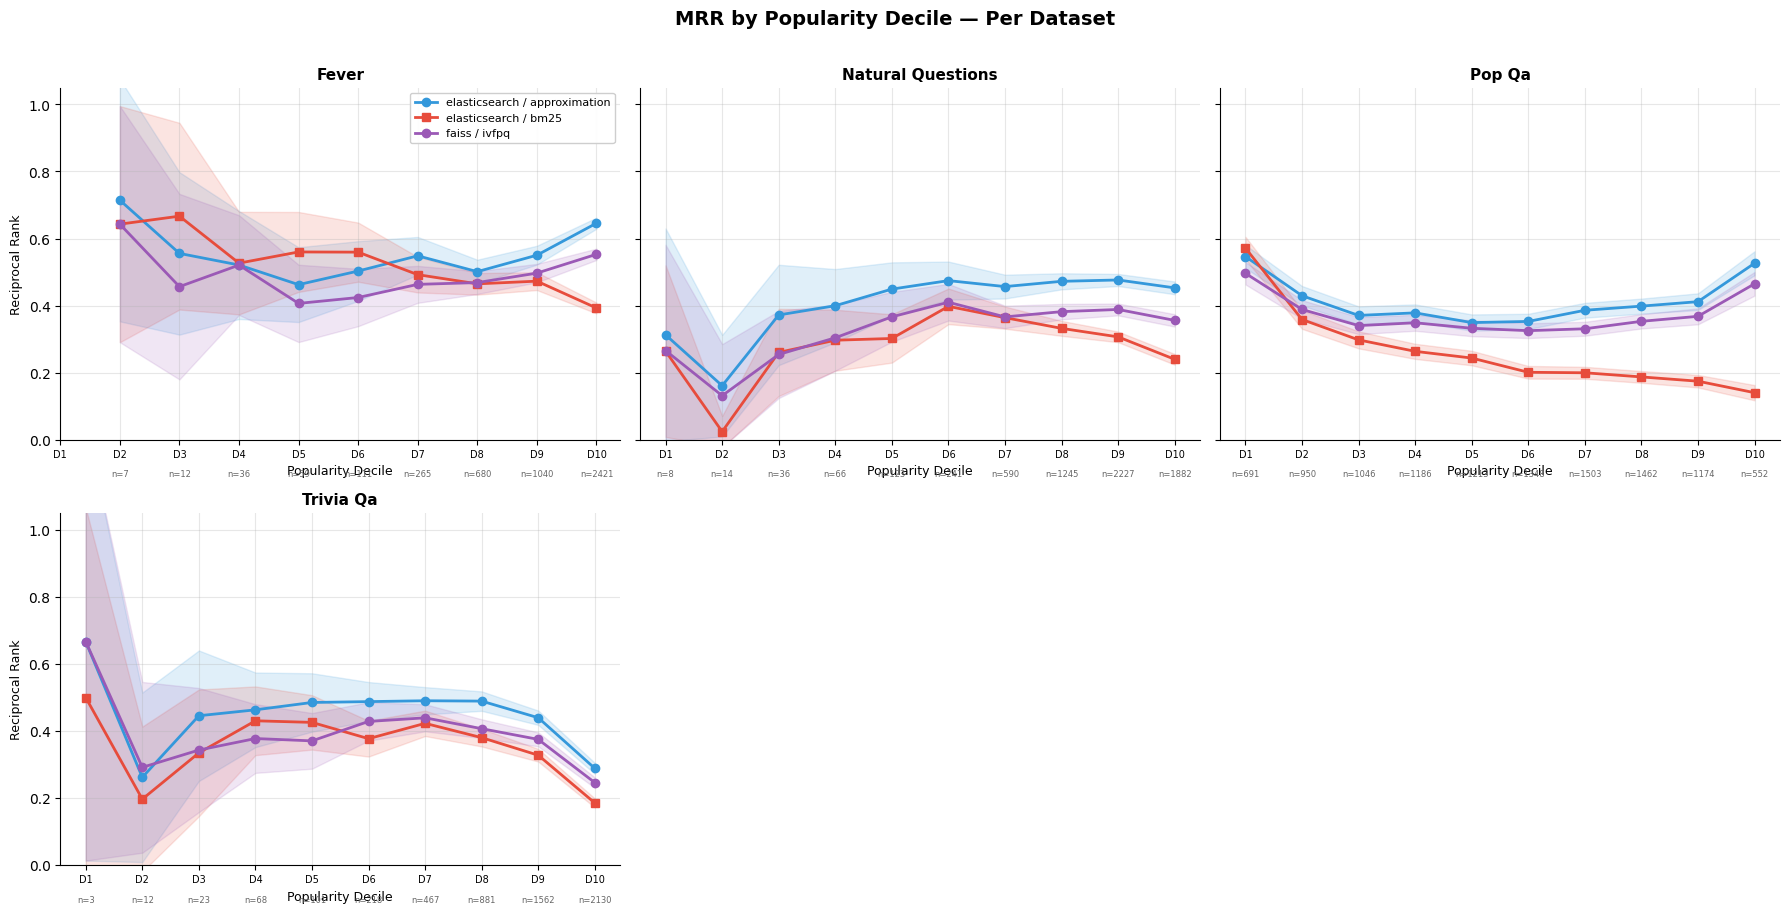

✓ Saved → per_dataset_decile_mrr.png


In [7]:
primary_k  = K_VALUES_DETAILED[-1]
recall_col = f"recall@{primary_k}"

if GROUP_COL:
    datasets = sorted(
        set().union(*[results_by_strategy[s][GROUP_COL].dropna().unique()
                       for s in ALL_STRATEGIES])
    )
    n_ds  = len(datasets)
    ncols = min(3, n_ds)
    nrows = (n_ds + ncols - 1) // ncols

    for metric, ylabel, title_suffix in [
        (recall_col,        f"Recall@{primary_k}", f"Recall@{primary_k}"),
        ("reciprocal_rank", "Reciprocal Rank",     "MRR"),
    ]:
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(6 * ncols, 4.5 * nrows),
                                 sharey=True, squeeze=False)
        axes_flat = axes.flatten()

        for idx, ds in enumerate(datasets):
            ax = axes_flat[idx]

            # collect per-decile n from the first strategy that has this dataset
            ref_n: dict[int, int] = {}
            for strategy in ALL_STRATEGIES:
                df  = results_by_strategy[strategy]
                sub = df[(df[GROUP_COL] == ds) & (df[decile_col] >= 0)]
                if sub.empty:
                    continue
                ref_n = sub.groupby(decile_col).size().to_dict()
                break  # same questions across strategies; one pass is enough

            for strategy in ALL_STRATEGIES:
                df  = results_by_strategy[strategy]
                sub = df[df[GROUP_COL] == ds].copy()
                if sub.empty or metric not in sub.columns:
                    continue
                sub = sub[sub[decile_col] >= 0]
                grp = (sub.groupby(decile_col)[metric]
                          .agg(mean="mean", sem=lambda v: v.std(ddof=1) / np.sqrt(len(v)))
                          .reset_index())
                grp.columns = ["decile", "mean", "sem"]
                ci = grp["sem"] * 1.96
                ax.plot(grp["decile"] + 1, grp["mean"],
                        marker=markers[strategy], linewidth=2,
                        color=strategy_colors[strategy],
                        label=strategy_label(strategy))
                ax.fill_between(grp["decile"] + 1,
                                grp["mean"] - ci, grp["mean"] + ci,
                                color=strategy_colors[strategy], alpha=0.15)

            # annotate n= below each decile tick
            for decile, n in sorted(ref_n.items()):
                ax.text(decile + 1, -0.085, f"n={n}",
                        ha="center", va="top", fontsize=6, color="#666666",
                        transform=ax.get_xaxis_transform())

            ax.set_title(ds.replace("_", " ").title(), fontsize=11, fontweight="bold")
            ax.set_xlabel("Popularity Decile", fontsize=9)
            ax.set_ylabel(ylabel if idx % ncols == 0 else "", fontsize=9)
            ax.set_xticks(range(1, 11))
            ax.set_xticklabels([f"D{d}" for d in range(1, 11)], fontsize=7)
            ax.set_ylim(0, 1.05)
            ax.grid(alpha=0.3)
            ax.spines[["top", "right"]].set_visible(False)
            if idx == 0:
                ax.legend(fontsize=8, framealpha=0.95)

        # hide unused subplots
        for idx in range(n_ds, len(axes_flat)):
            axes_flat[idx].set_visible(False)

        fig.suptitle(f"{title_suffix} by Popularity Decile — Per Dataset",
                     fontsize=14, fontweight="bold", y=1.01)
        plt.tight_layout()
        fname = f"per_dataset_decile_{metric.replace('@', '_at_').replace('reciprocal_rank', 'mrr')}.png"
        plt.savefig(RESULTS_DIR / fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✓ Saved → {fname}")
else:
    print("No GROUP_COL found — skipping per-dataset decile analysis.")


## Distance to Query Vector — Per-Decile Analysis

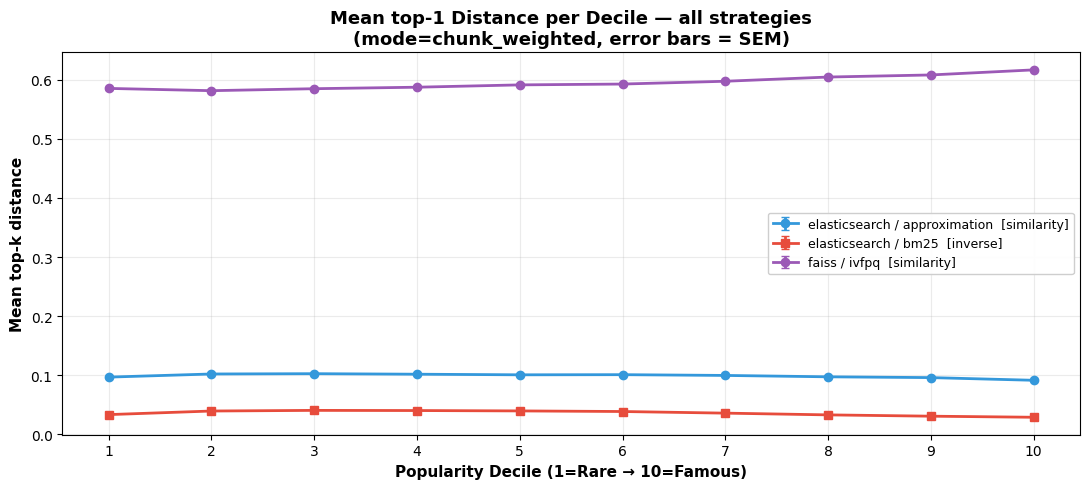

✓ Saved → distance_topk_all_strategies.png


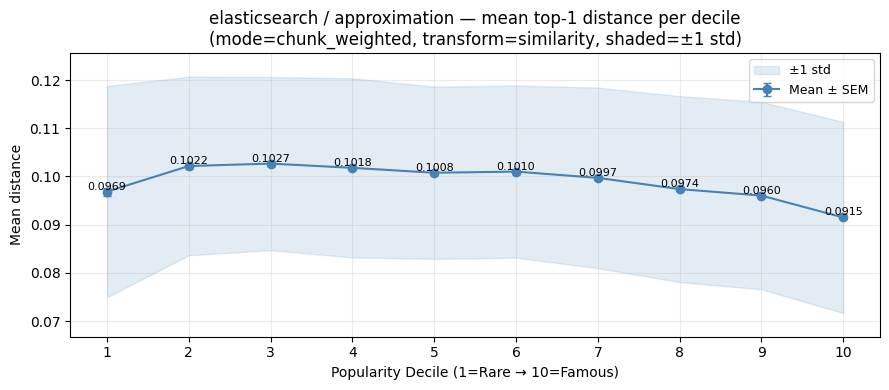

✓ Saved → distance_topk_approximation.png


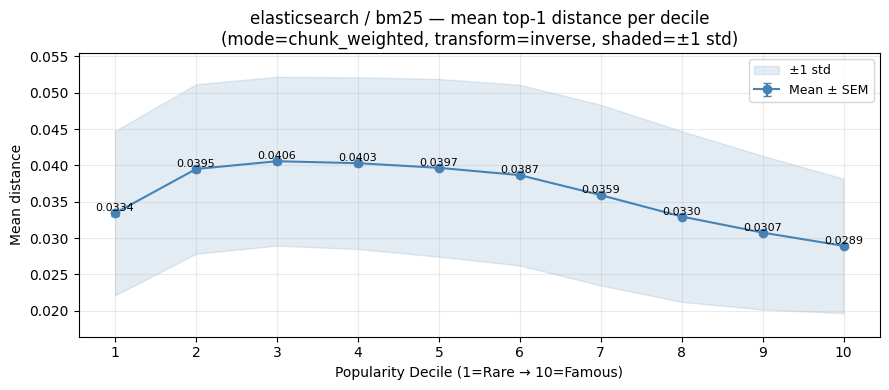

✓ Saved → distance_topk_bm25.png


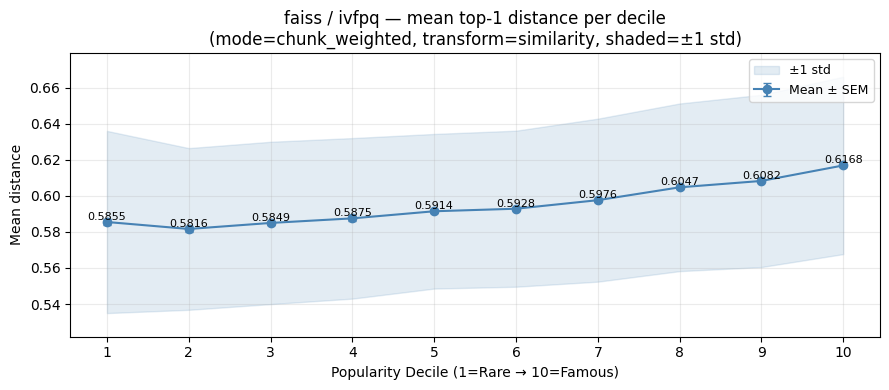

✓ Saved → distance_topk_ivfpq.png


In [8]:
import ast
from src.metrics.bias_utils import apply_transform, TRANSFORMS

rows = []
for strategy, df in results_by_strategy.items():
    for _, row in df.iterrows():
        dec = row.get(decile_col)
        if dec is None or pd.isna(dec):
            continue
        raw_scores = row.get('topk_scores')
        if raw_scores is None:
            continue
        if isinstance(raw_scores, str):
            try:
                raw_scores = ast.literal_eval(raw_scores)
            except Exception:
                continue
        try:
            iter(raw_scores)
        except TypeError:
            continue
        scores_list = [s for s in list(raw_scores)[:TOP_K] if s is not None]
        if not scores_list:
            continue
        dlist = [apply_transform(strategy, s) for s in scores_list]
        mean_dist = float(np.nanmean(dlist)) if dlist else np.nan
        rows.append({'strategy': strategy, decile_col: int(dec),
                     'mean_topk_distance': mean_dist, 'n_in_topk': len(scores_list)})

exp_df = pd.DataFrame(rows)
if exp_df.empty:
    print('No top-k scores found — check `topk_scores` column.')
else:
    agg = (exp_df.groupby(['strategy', decile_col])['mean_topk_distance']
           .agg(['mean', 'count', 'std']).reset_index())
    agg['sem'] = agg.apply(lambda r: r['std'] / np.sqrt(r['count']) if r['count'] > 0 else np.nan, axis=1)
    agg = agg.rename(columns={'mean': 'mean_distance'})
    (RESULTS_DIR / 'distance_topk_per_decile.csv').write_text(agg.to_csv(index=False))

    # ── Combined figure: all strategies on a single axis ─────────────────────
    fig, ax = plt.subplots(figsize=(11, 5))
    for strat in ALL_STRATEGIES:
        sub = agg[agg['strategy'] == strat].set_index(decile_col).reindex(range(10))
        x    = (sub.index + 1).values
        y    = sub['mean_distance'].values
        yerr = sub['sem'].values
        color = strategy_colors.get(strat, None)
        transform_mode = TRANSFORMS.get(strat, 'auto')
        ax.errorbar(x, y, yerr=yerr, marker=markers.get(strat, 'o'),
                    linewidth=2, markersize=6, capsize=3, color=color,
                    label=f'{strategy_label(strat)}  [{transform_mode}]')
    ax.set_xticks(range(1, 11))
    ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean top-k distance', fontsize=11, fontweight='bold')
    ax.set_title(f'Mean top-{TOP_K} Distance per Decile — all strategies\n'
                 f'(mode={DECILE_MODE}, error bars = SEM)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, framealpha=0.95)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'distance_topk_all_strategies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved → distance_topk_all_strategies.png')

    # ── Individual figure per strategy (with ±1 std band) ────────────────────
    for strat in ALL_STRATEGIES:
        sub = agg[agg['strategy'] == strat].set_index(decile_col).reindex(range(10))
        x    = (sub.index + 1).values
        y    = sub['mean_distance'].values
        yerr = sub['sem'].values
        ystd = sub['std'].values
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.fill_between(x, y - ystd, y + ystd, alpha=0.15, color='steelblue', label='±1 std')
        ax.errorbar(x, y, yerr=yerr, marker='o', linestyle='-', capsize=3,
                    color='steelblue', label='Mean ± SEM')
        valid = ~np.isnan(y) & ~np.isnan(ystd)
        if valid.any():
            pad = max((float((y + ystd)[valid].max()) - float((y - ystd)[valid].min())) * 0.10, 1e-6)
            ax.set_ylim(float((y - ystd)[valid].min()) - pad, float((y + ystd)[valid].max()) + pad)
        for xi, yi in zip(x, y):
            if not np.isnan(yi):
                ax.text(xi, yi, f'{yi:.4f}', ha='center', va='bottom', fontsize=8)
        transform_mode = TRANSFORMS.get(strat, 'auto')
        ax.set_title(f'{strategy_label(strat)} — mean top-{TOP_K} distance per decile\n'
                     f'(mode={DECILE_MODE}, transform={transform_mode}, shaded=±1 std)')
        ax.set_xticks(range(1, 11))
        ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)')
        ax.set_ylabel('Mean distance')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f'distance_topk_{strat}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✓ Saved → distance_topk_{strat}.png')
